# Data Understanding

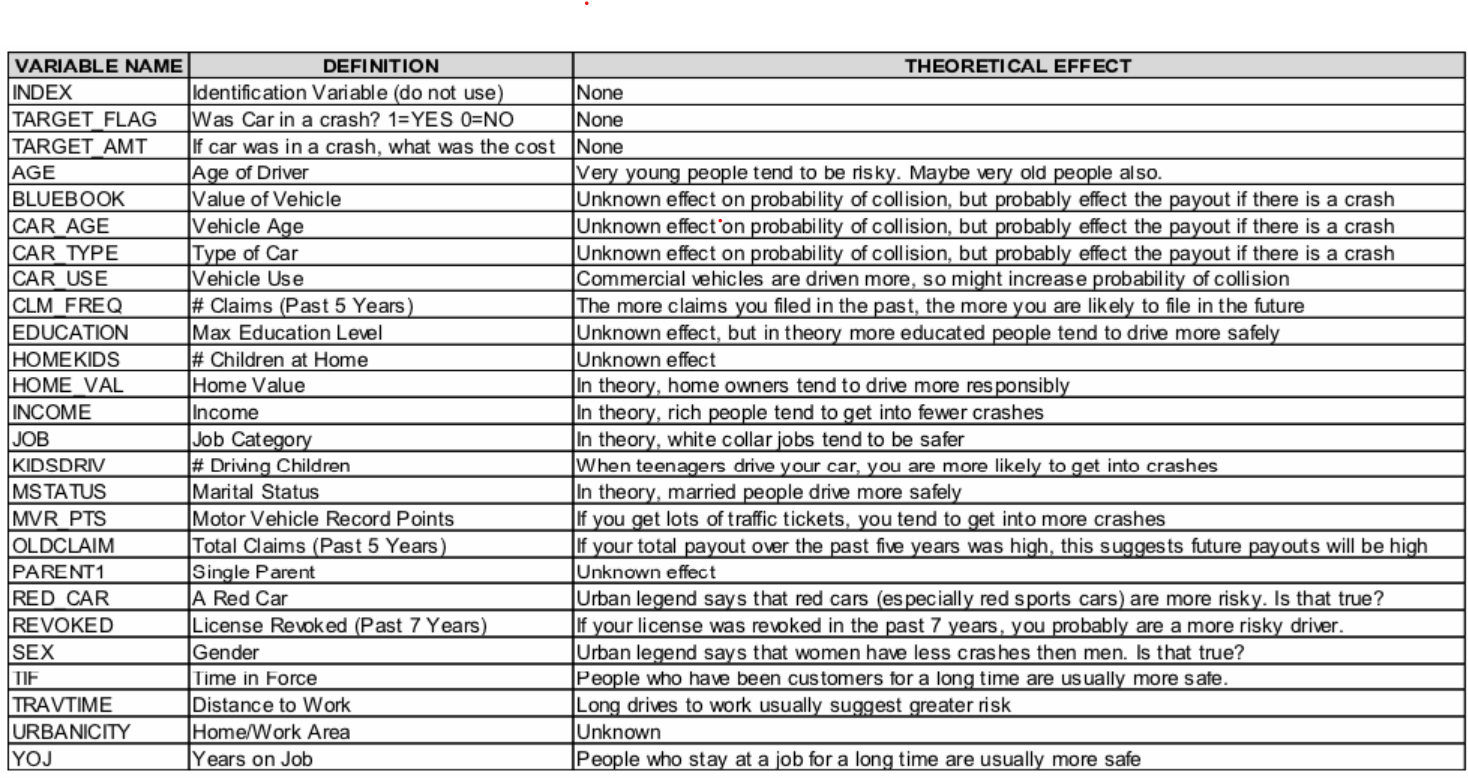

# Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
# Tow show all columns
pd.set_option('display.max_columns', None)

# Data Loading

In [3]:
df = pd.read_csv("car_insurance_claim.csv", index_col= 0)
df.head()

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16-Mar-39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21-Jan-56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18-Nov-51,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05-Mar-64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05-Jun-48,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,"$15,440",7,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban


In [4]:
# Convert all column names to lowercase

df.columns = df.columns.str.lower()
df.columns

Index(['id', 'kidsdriv', 'birth', 'age', 'homekids', 'yoj', 'income',
       'parent1', 'home_val', 'mstatus', 'gender', 'education', 'occupation',
       'travtime', 'car_use', 'bluebook', 'tif', 'car_type', 'red_car',
       'oldclaim', 'clm_freq', 'revoked', 'mvr_pts', 'clm_amt', 'car_age',
       'claim_flag', 'urbanicity'],
      dtype='object')

# Data Exploration

In [5]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          10302 non-null  int64  
 1   kidsdriv    10302 non-null  int64  
 2   birth       10302 non-null  object 
 3   age         10295 non-null  float64
 4   homekids    10302 non-null  int64  
 5   yoj         9754 non-null   float64
 6   income      9732 non-null   object 
 7   parent1     10302 non-null  object 
 8   home_val    9727 non-null   object 
 9   mstatus     10302 non-null  object 
 10  gender      10302 non-null  object 
 11  education   10302 non-null  object 
 12  occupation  9637 non-null   object 
 13  travtime    10302 non-null  int64  
 14  car_use     10302 non-null  object 
 15  bluebook    10302 non-null  object 
 16  tif         10302 non-null  int64  
 17  car_type    10302 non-null  object 
 18  red_car     10302 non-null  object 
 19  oldclaim    10302 non-null  ob

In [6]:
df.head(2)

,id,kidsdriv,birth,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity
0,63581743,0,16-Mar-39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21-Jan-56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban


In [7]:
# Check Summary statistics for Numerical Columns
df.describe().round(2)

,id,kidsdriv,age,homekids,yoj,travtime,tif,clm_freq,mvr_pts,car_age,claim_flag
count,1.030200e+04,10302.00,10295.00,10302.00,9754.00,10302.00,10302.00,10302.00,10302.00,9663.00,10302.00
mean,4.956631e+08,0.17,44.84,0.72,10.47,33.42,5.33,0.80,1.71,8.30,0.27
std,2.864675e+08,0.51,8.61,1.12,4.11,15.87,4.11,1.15,2.16,5.71,0.44
min,6.317500e+04,0.00,16.00,0.00,0.00,5.00,1.00,0.00,0.00,-3.00,0.00
25%,2.442869e+08,0.00,39.00,0.00,9.00,22.00,1.00,0.00,0.00,1.00,0.00
50%,4.970043e+08,0.00,45.00,0.00,11.00,33.00,4.00,0.00,1.00,8.00,0.00
75%,7.394551e+08,0.00,51.00,1.00,13.00,44.00,7.00,2.00,3.00,12.00,1.00
max,9.999264e+08,4.00,81.00,5.00,23.00,142.00,25.00,5.00,13.00,28.00,1.00


In [8]:
# Check Summary statistics for Categorical Columns
df.describe(include= ['object']).drop(['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt'], axis= 1)

,birth,parent1,mstatus,gender,education,occupation,car_use,car_type,red_car,revoked,urbanicity
count,10302,10302,10302,10302,10302,9637,10302,10302,10302,10302,10302
unique,6560,2,2,2,5,8,2,6,2,2,2
top,20-Oct-60,No,Yes,z_F,z_High School,z_Blue Collar,Private,z_SUV,no,No,Highly Urban/ Urban
freq,8,8959,6188,5545,2952,2288,6513,2883,7326,9041,8230


In [9]:
# Check duplicates
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace= True, ignore_index= True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(10301, 27)

In [13]:
# Check Missing Values by count
df.isna().sum()

id              0
kidsdriv        0
birth           0
age             7
homekids        0
yoj           548
income        570
parent1         0
home_val      575
mstatus         0
gender          0
education       0
occupation    665
travtime        0
car_use         0
bluebook        0
tif             0
car_type        0
red_car         0
oldclaim        0
clm_freq        0
revoked         0
mvr_pts         0
clm_amt         0
car_age       639
claim_flag      0
urbanicity      0
dtype: int64

In [14]:
df.isna().mean().round(4) * 100

id            0.00
kidsdriv      0.00
birth         0.00
age           0.07
homekids      0.00
yoj           5.32
income        5.53
parent1       0.00
home_val      5.58
mstatus       0.00
gender        0.00
education     0.00
occupation    6.46
travtime      0.00
car_use       0.00
bluebook      0.00
tif           0.00
car_type      0.00
red_car       0.00
oldclaim      0.00
clm_freq      0.00
revoked       0.00
mvr_pts       0.00
clm_amt       0.00
car_age       6.20
claim_flag    0.00
urbanicity    0.00
dtype: float64

In [15]:
# 95% in case same NaNs in all columns

# 75% in case different NaNs in all columns

In [16]:
df.dropna()

,id,kidsdriv,birth,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,claim_flag,urbanicity
0,63581743,0,16-Mar-39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21-Jan-56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18-Nov-51,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05-Mar-64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
6,871024631,0,05-May-65,34.0,1,12.0,"$125,301",Yes,$0,z_No,z_F,Bachelors,z_Blue Collar,46,Commercial,"$17,430",1,Sports Car,no,$0,0,No,0,"$2,946",7.0,1,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10295,121441578,0,01-Jul-64,35.0,0,11.0,"$43,112",No,$0,z_No,M,z_High School,z_Blue Collar,51,Commercial,"$27,330",10,Panel Truck,yes,$0,0,No,0,$0,8.0,0,z_Highly Rural/ Rural
10296,67790126,1,13-Aug-54,45.0,2,9.0,"$164,669",No,"$386,273",Yes,M,PhD,Manager,21,Private,"$13,270",15,Minivan,no,$0,0,No,2,$0,17.0,0,Highly Urban/ Urban
10298,849208064,0,18-Jun-51,48.0,0,15.0,"$39,837",No,"$170,611",Yes,z_F,<High School,z_Blue Collar,12,Private,"$13,820",7,z_SUV,no,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
10299,627828331,0,12-Dec-48,50.0,0,7.0,"$43,445",No,"$149,248",Yes,z_F,Bachelors,Home Maker,36,Private,"$22,550",6,Minivan,no,$0,0,No,0,$0,11.0,0,Highly Urban/ Urban


In [17]:
round(df.dropna().shape[0] / df.shape[0] * 100, 2)

74.32

# Data Cleaning

In [18]:
# Drop unnecessary columns

df.drop(['id', 'birth'], axis= 1, inplace= True)

In [19]:
df.duplicated().sum()

np.int64(0)

#### In depth check for categorical columns

In [20]:
cat_cols = df.select_dtypes(include= 'object').drop(['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt'], axis= 1).columns
cat_cols

Index(['parent1', 'mstatus', 'gender', 'education', 'occupation', 'car_use',
       'car_type', 'red_car', 'revoked', 'urbanicity'],
      dtype='object')

In [21]:
for col in cat_cols:

    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-' * 100)

parent1
2
['No' 'Yes']
----------------------------------------------------------------------------------------------------
mstatus
2
['z_No' 'Yes']
----------------------------------------------------------------------------------------------------
gender
2
['M' 'z_F']
----------------------------------------------------------------------------------------------------
education
5
['PhD' 'z_High School' 'Bachelors' '<High School' 'Masters']
----------------------------------------------------------------------------------------------------
occupation
8
['Professional' 'z_Blue Collar' 'Manager' 'Clerical' 'Doctor' 'Lawyer' nan
 'Home Maker' 'Student']
----------------------------------------------------------------------------------------------------
car_use
2
['Private' 'Commercial']
----------------------------------------------------------------------------------------------------
car_type
6
['Minivan' 'Van' 'z_SUV' 'Sports Car' 'Panel Truck' 'Pickup']
-------------------------------

In [22]:
df[['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt']]

,income,home_val,bluebook,oldclaim,clm_amt
0,"$67,349",$0,"$14,230","$4,461",$0
1,"$91,449","$257,252","$14,940",$0,$0
2,"$52,881",$0,"$21,970",$0,$0
3,"$16,039","$124,191","$4,010","$38,690",$0
4,NaN,"$306,251","$15,440",$0,$0
...,...,...,...,...,...
10296,"$164,669","$386,273","$13,270",$0,$0
10297,"$107,204","$332,591","$24,490",$0,$0
10298,"$39,837","$170,611","$13,820",$0,$0
10299,"$43,445","$149,248","$22,550",$0,$0


In [23]:
# '$67,349'.replace('$', '')
'$67,349'.strip('$')

'67,349'

In [24]:
float('$67,349'.replace('$', '').replace(',', ''))

67349.0

In [25]:
def clean_data_types(x):

    if type(x) == float:

        return x
    
    else:
        return float(x.replace('$', '').replace(',', ''))

for col in ['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt']:

    df[col] = df[col].apply(clean_data_types)

In [26]:
df[['income', 'home_val', 'bluebook', 'oldclaim', 'clm_amt']]

,income,home_val,bluebook,oldclaim,clm_amt
0,67349.0,0.0,14230.0,4461.0,0.0
1,91449.0,257252.0,14940.0,0.0,0.0
2,52881.0,0.0,21970.0,0.0,0.0
3,16039.0,124191.0,4010.0,38690.0,0.0
4,NaN,306251.0,15440.0,0.0,0.0
...,...,...,...,...,...
10296,164669.0,386273.0,13270.0,0.0,0.0
10297,107204.0,332591.0,24490.0,0.0,0.0
10298,39837.0,170611.0,13820.0,0.0,0.0
10299,43445.0,149248.0,22550.0,0.0,0.0


In [27]:
df[['gender', 'education', 'occupation', 'car_type', 'mstatus', 'urbanicity']]

,gender,education,occupation,car_type,mstatus,urbanicity
0,M,PhD,Professional,Minivan,z_No,Highly Urban/ Urban
1,M,z_High School,z_Blue Collar,Minivan,z_No,Highly Urban/ Urban
2,M,Bachelors,Manager,Van,z_No,Highly Urban/ Urban
3,z_F,z_High School,Clerical,z_SUV,Yes,Highly Urban/ Urban
4,M,<High School,z_Blue Collar,Minivan,Yes,Highly Urban/ Urban
...,...,...,...,...,...,...
10296,M,PhD,Manager,Minivan,Yes,Highly Urban/ Urban
10297,M,Masters,NaN,Panel Truck,Yes,Highly Urban/ Urban
10298,z_F,<High School,z_Blue Collar,z_SUV,Yes,Highly Urban/ Urban
10299,z_F,Bachelors,Home Maker,Minivan,Yes,Highly Urban/ Urban


In [28]:
# 'z_Blue Collar'.replace('z_', '')
# 'z_Blue Collar'.strip('z_')
'z_Blue Collar'[2:]

'Blue Collar'

In [29]:
def remove_z(x):

    if type(x) == float:
        return x

    else:
        return x.strip('z_')

for col in ['gender', 'education', 'occupation', 'car_type', 'mstatus', 'urbanicity']:

    df[col] = df[col].apply(remove_z)

In [30]:
df[['gender', 'education', 'occupation', 'car_type', 'mstatus', 'urbanicity']]

,gender,education,occupation,car_type,mstatus,urbanicity
0,M,PhD,Professional,Minivan,No,Highly Urban/ Urban
1,M,High School,Blue Collar,Minivan,No,Highly Urban/ Urban
2,M,Bachelors,Manager,Van,No,Highly Urban/ Urban
3,F,High School,Clerical,SUV,Yes,Highly Urban/ Urban
4,M,<High School,Blue Collar,Minivan,Yes,Highly Urban/ Urban
...,...,...,...,...,...,...
10296,M,PhD,Manager,Minivan,Yes,Highly Urban/ Urban
10297,M,Masters,NaN,Panel Truck,Yes,Highly Urban/ Urban
10298,F,<High School,Blue Collar,SUV,Yes,Highly Urban/ Urban
10299,F,Bachelors,Home Maker,Minivan,Yes,Highly Urban/ Urban


#### In depth check for numerical columns

In [31]:
# df.select_dtypes(include= [int, float])
num_cols = df.select_dtypes(include= 'number').columns
num_cols

Index(['kidsdriv', 'age', 'homekids', 'yoj', 'income', 'home_val', 'travtime',
       'bluebook', 'tif', 'oldclaim', 'clm_freq', 'mvr_pts', 'clm_amt',
       'car_age', 'claim_flag'],
      dtype='object')

In [32]:
for col in num_cols:

    px.histogram(data_frame= df, x= col).show()

In [33]:
df.car_age = df.car_age.abs()
df.car_age

0        18.0
1         1.0
2        10.0
3        10.0
4         6.0
         ... 
10296    17.0
10297     1.0
10298     1.0
10299    11.0
10300     9.0
Name: car_age, Length: 10301, dtype: float64

In [34]:
px.histogram(data_frame= df, x= 'car_age')

In [35]:
# Drop Missing values in age column
df.dropna(subset= 'age', inplace= True, ignore_index= True)

In [36]:
df.isna().sum()

kidsdriv        0
age             0
homekids        0
yoj           548
income        569
parent1         0
home_val      573
mstatus         0
gender          0
education       0
occupation    665
travtime        0
car_use         0
bluebook        0
tif             0
car_type        0
red_car         0
oldclaim        0
clm_freq        0
revoked         0
mvr_pts         0
clm_amt         0
car_age       639
claim_flag      0
urbanicity      0
dtype: int64

In [37]:
df.to_csv('cleaned_df.csv', index= False)

# Pipeline

### Split Data into Input & Output Features

In [38]:
x = df.drop('claim_flag', axis= 1)
y = df['claim_flag']

### Numerical Pipeline

- Num Pipeline 1

In [39]:
num_cols_1 = ['yoj', 'car_age']
num_cols_1

['yoj', 'car_age']

In [40]:
# yoj & car_age
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

imputer = SimpleImputer(strategy= 'median')
scaler = RobustScaler()

num_pipeline_1 = Pipeline([ ('Median Impute', imputer),
                            ('Robust Scaler', scaler)])
num_pipeline_1

Pipeline(steps=[('Median Impute', SimpleImputer(strategy='median')),
                ('Robust Scaler', RobustScaler())])

- Num Pipeline 2

In [41]:
num_cols_2 = x.select_dtypes(include= 'number').columns.drop(num_cols_1)
num_cols_2

Index(['kidsdriv', 'age', 'homekids', 'income', 'home_val', 'travtime',
       'bluebook', 'tif', 'oldclaim', 'clm_freq', 'mvr_pts', 'clm_amt'],
      dtype='object')

In [42]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer()

num_pipeline_2 = Pipeline(steps= [ ('Knn Impute', knn_imputer),
                                   ('Robust Scaler', scaler) ])
num_pipeline_2

Pipeline(steps=[('Knn Impute', KNNImputer()),
                ('Robust Scaler', RobustScaler())])

### Categorical Pipeline

In [43]:
x.select_dtypes(include= 'object')

,parent1,mstatus,gender,education,occupation,car_use,car_type,red_car,revoked,urbanicity
0,No,No,M,PhD,Professional,Private,Minivan,yes,No,Highly Urban/ Urban
1,No,No,M,High School,Blue Collar,Commercial,Minivan,yes,No,Highly Urban/ Urban
2,No,No,M,Bachelors,Manager,Private,Van,yes,No,Highly Urban/ Urban
3,No,Yes,F,High School,Clerical,Private,SUV,no,No,Highly Urban/ Urban
4,No,Yes,M,<High School,Blue Collar,Private,Minivan,yes,No,Highly Urban/ Urban
...,...,...,...,...,...,...,...,...,...,...
10289,No,Yes,M,PhD,Manager,Private,Minivan,no,No,Highly Urban/ Urban
10290,No,Yes,M,Masters,NaN,Commercial,Panel Truck,no,No,Highly Urban/ Urban
10291,No,Yes,F,<High School,Blue Collar,Private,SUV,no,No,Highly Urban/ Urban
10292,No,Yes,F,Bachelors,Home Maker,Private,Minivan,no,No,Highly Urban/ Urban


In [44]:
x.occupation.value_counts(normalize= True) * 100

occupation
Blue Collar     23.761554
Clerical        16.491848
Professional    14.612109
Manager         13.054315
Lawyer          10.707239
Student          9.305224
Home Maker       8.734033
Doctor           3.333680
Name: proportion, dtype: float64

- Binary Encoder Pipeline

In [45]:
BE_cols = ['occupation']
BE_cols

['occupation']

In [54]:
from category_encoders import BinaryEncoder

imputer = SimpleImputer(strategy= 'constant', fill_value= 'Other')
BE = BinaryEncoder()

BE_pipeline = Pipeline(steps= [ ('Constant Impute', imputer),
                                        ('Binary Encode', BE) ])
BE_pipeline

Pipeline(steps=[('Constant Impute',
                 SimpleImputer(fill_value='Other', strategy='constant')),
                ('Binary Encode', BinaryEncoder())])

- Ordinal Pipeline

In [47]:
ord_cols = ['education']
ord_cols

['education']

In [48]:
from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder(categories= [ ['<High School', 'High School', 'Bachelors', 'Masters', 'PhD'] ])

ord_pipeline = Pipeline(steps= [ ('Ordinal Encoder', ord) ])
ord_pipeline

Pipeline(steps=[('Ordinal Encoder',
                 OrdinalEncoder(categories=[['<High School', 'High School',
                                             'Bachelors', 'Masters',
                                             'PhD']]))])

In [49]:
cat_cols = x.select_dtypes(include= 'object').columns

for col in cat_cols:

    print(col)
    print(df[col].nunique())

parent1
2
mstatus
2
gender
2
education
5
occupation
8
car_use
2
car_type
6
red_car
2
revoked
2
urbanicity
2


- OHE Pipeline

In [50]:
ohe_cols = cat_cols.drop(['education', 'occupation'])
ohe_cols

Index(['parent1', 'mstatus', 'gender', 'car_use', 'car_type', 'red_car',
       'revoked', 'urbanicity'],
      dtype='object')

In [51]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop= 'first', sparse_output= False)

ohe_pipeline = Pipeline(steps= [ ('OHE', ohe) ])
ohe_pipeline

Pipeline(steps=[('OHE', OneHotEncoder(drop='first', sparse_output=False))])

### Assign each column to the corresponding pipeline

In [52]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer(transformers= [ ('Num Pipeline 1', num_pipeline_1, num_cols_1),
                                  ('Num Pipeline 2', num_pipeline_2, num_cols_2),
                                  ('BE Pipeline', BE_pipeline, BE_cols),
                                  ('Ord Pipeline', ord_pipeline, ord_cols),
                                  ('OHE Pipeline', ohe_pipeline, ohe_cols)],
                                  remainder= 'passthrough')
preprocessing

ColumnTransformer(remainder='passthrough',
                  transformers=[('Num Pipeline 1',
                                 Pipeline(steps=[('Median Impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('Robust Scaler',
                                                  RobustScaler())]),
                                 ['yoj', 'car_age']),
                                ('Num Pipeline 2',
                                 Pipeline(steps=[('Knn Impute', KNNImputer()),
                                                 ('Robust Scaler',
                                                  RobustScaler())]),
                                 Index(['kidsdriv', 'age', 'homekids', 'income', 'home_val', 'travtime',...
                                ('Ord Pipeline',
                                 Pipeline(steps=[('Ordinal Encoder',
                                                  OrdinalEncoder(categories=[['<High '
                                                                              'School',
                                                                              'High '
                                                                              'School',
                                                                              'Bachelors',
                                                                              'Masters',
                                                                              'PhD']]))]),
                                 ['education']),
                                ('OHE Pipeline',
                                 Pipeline(steps=[('OHE',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 Index(['parent1', 'mstatus', 'gender', 'car_use', 'car_type', 'red_car',
       'revoked', 'urbanicity'],
      dtype='object'))])

In [ ]:
# ! pip install imblearn

In [57]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

smote = SMOTE()
lr = LogisticRegression()

model_pipeline = Pipeline(steps= [ ('Preprocessing', preprocessing),
                                   ('SMOTE', smote),
                                   ('Model', lr)])
model_pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Num Pipeline 1',
                                                  Pipeline(steps=[('Median '
                                                                   'Impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['yoj', 'car_age']),
                                                 ('Num Pipeline 2',
                                                  Pipeline(steps=[('Knn Impute',
                                                                   KNNImputer()),
                                                                  ('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  Index(['kidsdriv', 'age', 'ho...
                                                                   OrdinalEncoder(categories=[['<High '
                                                                                               'School',
                                                                                               'High '
                                                                                               'School',
                                                                                               'Bachelors',
                                                                                               'Masters',
                                                                                               'PhD']]))]),
                                                  ['education']),
                                                 ('OHE Pipeline',
                                                  Pipeline(steps=[('OHE',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['parent1', 'mstatus', 'gender', 'car_use', 'car_type', 'red_car',
       'revoked', 'urbanicity'],
      dtype='object'))])),
                ('SMOTE', SMOTE()), ('Model', LogisticRegression())])

### Select Best Model

In [ ]:
# ! pip install catboost
# ! pip install lightgbm

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---

In [61]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

models = [
    ('Logistic Regression', LogisticRegression(random_state= 42, n_jobs= -1)),
    ('KNN', KNeighborsClassifier(n_jobs= -1)),
    ('Gaussian NB', GaussianNB()),
    ('Decision Tree', DecisionTreeClassifier(random_state= 42)),
    ('Random Forest', RandomForestClassifier(random_state= 42, n_jobs= -1)),
    ('XGBoost', XGBClassifier()),
    ('CatBoost', CatBoostClassifier()),
    ('LightGBM', LGBMClassifier())
]

for model in models:

    model_pipeline = Pipeline(steps= [ ('Preprocessing', preprocessing),
                                       ('SMOTE', smote),
                                       ('Model', model[1])])
    
    result = cross_validate(model_pipeline, x, y, cv= 5, scoring= 'f1', return_train_score= True, n_jobs= -1)

    print(model[0])
    print('Train F1 Score :', round(result['train_score'].mean() * 100, 2))
    print('Test F1 Score :', round(result['test_score'].mean() * 100, 2))
    print('-' * 50)

Logistic Regression
Train F1 Score : 99.64
Test F1 Score : 99.6
--------------------------------------------------
KNN
Train F1 Score : 97.61
Test F1 Score : 93.85
--------------------------------------------------
Gaussian NB
Train F1 Score : 99.32
Test F1 Score : 99.2
--------------------------------------------------
Decision Tree
Train F1 Score : 100.0
Test F1 Score : 100.0
--------------------------------------------------
Random Forest
Train F1 Score : 100.0
Test F1 Score : 99.96
--------------------------------------------------
XGBoost
Train F1 Score : 100.0
Test F1 Score : 99.65
--------------------------------------------------
CatBoost
Train F1 Score : 100.0
Test F1 Score : 100.0
--------------------------------------------------
LightGBM
Train F1 Score : 100.0
Test F1 Score : 100.0
--------------------------------------------------


In [62]:
result

{'fit_time': array([11.70299911, 11.68682456, 11.15350533, 11.40199828,  2.13372231]),
 'score_time': array([0.64899039, 0.72387838, 0.72628641, 0.75477195, 0.42493844]),
 'test_score': array([1., 1., 1., 1., 1.]),
 'train_score': array([1., 1., 1., 1., 1.])}

### The Best Model (LightGBM)

In [63]:
LGBM_Model = Pipeline(steps= [  ('Preprocessing', preprocessing),
                                    ('SMOTE', smote),
                                    ('Model', LGBMClassifier())])
LGBM_Model

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Num Pipeline 1',
                                                  Pipeline(steps=[('Median '
                                                                   'Impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['yoj', 'car_age']),
                                                 ('Num Pipeline 2',
                                                  Pipeline(steps=[('Knn Impute',
                                                                   KNNImputer()),
                                                                  ('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  Index(['kidsdriv', 'age', 'ho...
                                                                   OrdinalEncoder(categories=[['<High '
                                                                                               'School',
                                                                                               'High '
                                                                                               'School',
                                                                                               'Bachelors',
                                                                                               'Masters',
                                                                                               'PhD']]))]),
                                                  ['education']),
                                                 ('OHE Pipeline',
                                                  Pipeline(steps=[('OHE',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['parent1', 'mstatus', 'gender', 'car_use', 'car_type', 'red_car',
       'revoked', 'urbanicity'],
      dtype='object'))])),
                ('SMOTE', SMOTE()), ('Model', LGBMClassifier())])

In [64]:


LGBM_Model.fit(x, y)

c:\Users\Samier\anaconda3\envs\ml\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


[LightGBM] [Info] Number of positive: 7554, number of negative: 7554
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7724
[LightGBM] [Info] Number of data points in the train set: 15108, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Num Pipeline 1',
                                                  Pipeline(steps=[('Median '
                                                                   'Impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['yoj', 'car_age']),
                                                 ('Num Pipeline 2',
                                                  Pipeline(steps=[('Knn Impute',
                                                                   KNNImputer()),
                                                                  ('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  Index(['kidsdriv', 'age', 'ho...
                                                                   OrdinalEncoder(categories=[['<High '
                                                                                               'School',
                                                                                               'High '
                                                                                               'School',
                                                                                               'Bachelors',
                                                                                               'Masters',
                                                                                               'PhD']]))]),
                                                  ['education']),
                                                 ('OHE Pipeline',
                                                  Pipeline(steps=[('OHE',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['parent1', 'mstatus', 'gender', 'car_use', 'car_type', 'red_car',
       'revoked', 'urbanicity'],
      dtype='object'))])),
                ('SMOTE', SMOTE()), ('Model', LGBMClassifier())])

In [65]:
x.head(1)

,kidsdriv,age,homekids,yoj,income,parent1,home_val,mstatus,gender,education,occupation,travtime,car_use,bluebook,tif,car_type,red_car,oldclaim,clm_freq,revoked,mvr_pts,clm_amt,car_age,urbanicity
0,0,60.0,0,11.0,67349.0,No,0.0,No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,4461.0,2,No,3,0.0,18.0,Highly Urban/ Urban


In [66]:
LGBM_Model.predict(x.head(1))[0]

c:\Users\Samier\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


np.int64(0)

In [67]:
#! pip install joblib

In [69]:
import joblib

joblib.dump(LGBM_Model, 'LGBM_Model.pkl')

['LGBM_Model.pkl']

# Deployment

In [ ]:
import streamlit as st

In [ ]:
# streamlit app
%%writefile car_insurance.py

import streamlit as st
import pandas as pd
import joblib
from imblearn.pipeline import  Pipeline
from sklearn.impute import  SimpleImputer, KNNImputer
from sklearn.preprocessing import  RobustScaler, OneHotEncoder, OrdinalEncoder
from category_encoders import  BinaryEncoder
from imblearn.over_sampling import  SMOTE
from sklearn.neighbors import KNeighborsClassifier

st.set_page_config(layout= 'wide', page_title= 'Car Insurance Project')

html_title = "<h1 style=color:white;text-align:center;> Car Insurance Classification Project </h1>"
st.markdown(html_title, unsafe_allow_html=True)

st.image('https://prod.cosy.bmw.cloud/bmwweb/cosySec?COSY-EU-100-2545xM4RIyFnbm9Mb3AgyyIJrjG0suyJRBODlsrjGpuaprQbhSIqppglBgMxEJl384MlficYiGHqoQxYLW7%25f3tiJ0PCJirQbLDWcQW7%251uNRrqoQh47wMvcYi9t5BJMb3islBglUUJecRScH8R4MbnMdoPeyJGy53LvrQ%25r9YaJW8zWuEJQqogqaFQ7l3ilUjzJcRScH78lMbnMd0zqyJGy5iubrQ%25r9SbUW8zWunDjqogqaG4zl3ilU%25QocRScHzUVMbnMdg4ayJGy5iJUrQ%25r9saYW8zWuKbGqogqaDJKl3ilUCQIcRScH4%25bMbnMdJmSyJGy5Q3SrQ%25r98R5W8zWuobuqogqa3Jnl3ilUR%25gcRScHbU8MbnMdJbkyJGy5Q4ErQ%25r993UW8zWuu3HqogqaaUbl3ilUjv0cRSrQdr9SMBW8zcRacHHwsMbnW85WuEfuqoQEdcNq0zxcqW8JuzM8nq0z6Fboy6oEd82')

df = pd.read_csv('cleaned_df.csv')
st.dataframe(df)

kidsdriv = st.selectbox('PLease provid number of driving kids', df.kidsdriv.unique())
age = st.sidebar.slider('Enter your Age', min_value= 16, max_value= 81, step= 1)
homekids = st.selectbox('PLease provid total number of kids', df.homekids.unique())
yoj = st.sidebar.slider('Please provide number of years on job', min_value= int(df.yoj.min()), max_value= int(df.yoj.max()), step= 1)
income = st.number_input('Please provide your income', min_value= df.income.min(), max_value= df.income.max())
parent1 = st.selectbox('PLease select whether you are single parent or not', df.parent1.unique())
home_val = st.number_input('Please provide your home value', min_value= df.home_val.min(), max_value= df.home_val.max())
mstatus = st.sidebar.radio('Marital Status', df.mstatus.unique())
gender = st.sidebar.radio('Gender', df.gender.unique())
education = st.selectbox('Please enter your educational background', df.education.unique())
occupation = st.selectbox('Please enter your Occupation', df.occupation.unique())
travtime = st.sidebar.slider('Please enter your travel time in minutes', min_value= df.travtime.min(), max_value= df.travtime.max(), step= 1)
car_use = st.selectbox('PLease provid your car usage', df.car_use.unique())
bluebook = st.number_input('Please provide your car value', min_value= df.bluebook.min(), max_value= df.bluebook.max())
tif = st.sidebar.slider('Loyalty years', min_value= df.tif.min(), max_value= df.tif.max(), step= 1)
car_type = st.selectbox('PLease provid your car type', df.car_type.unique())
red_car = st.selectbox('Red car or Not', df.red_car.unique())
oldclaim = st.number_input('Please provide your old claim amount', min_value= df.oldclaim.min(), max_value= df.oldclaim.max())
clm_freq = st.sidebar.slider('Please provide number of previous claims', min_value= df.clm_freq.min(), max_value= df.clm_freq.max(), step= 1)
revoked = st.selectbox('License Revoked within 7 years', df.revoked.unique())
mvr_pts = st.sidebar.slider('Please provide vechile record points', min_value= df.mvr_pts.min(), max_value= df.mvr_pts.max(), step= 1)
clm_amt = st.number_input('Please provide your total claims amount', min_value= df.clm_amt.min(), max_value= df.clm_amt.max())
car_age = st.sidebar.slider('Please enter your car age', min_value= int(df.car_age.min()), max_value= int(df.car_age.max()), step= 1)
urbanicity = st.selectbox('Urbanicity', df.urbanicity.unique())

# Import Model
Model = joblib.load('LGBM_Model.pkl')

input_cols = df.columns.drop('claim_flag')

new_data = pd.DataFrame(columns= input_cols, data= [ [kidsdriv, age, homekids, yoj, income, parent1, home_val,
                                           mstatus, gender, education, occupation, travtime, car_use,
                                           bluebook, tif, car_type, red_car, oldclaim, clm_freq,
                                           revoked, mvr_pts, clm_amt, car_age, urbanicity] ])

if st.button('Predict'):

    result = Model.predict(new_data)[0]

    if result == 0:
        st.write('Claim Flag : NO')

    else:
        st.write('Claim Flag : YES')

Overwriting car_insurance.py


In [ ]:
! streamlit run car_insurance.py

^C


In [ ]:
# to generate requirements.txt file
import pipreqs

! pipreqs .

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in .\requirements.txt
